## 1. Data in Python Request

In [ ]:
import pandas as pd

In [ ]:
# reading excel file 'Run Times.xlsx' and storing it in variable run_times
run_times = pd.read_excel('Run Times.xlsx')

In [ ]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,$0.00
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,$0.00
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,False,$2.50
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,$0.00
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,False,$2.50


In [ ]:
# checking data types
run_times.dtypes

Name                       str
Run Time               float64
Warm Up Time            object
Location                   str
Run Date        datetime64[us]
Race Date       datetime64[us]
Rain                      bool
Fee                        str
dtype: object

In [ ]:
run_times.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Name          5 non-null      str           
 1   Run Time      5 non-null      float64       
 2   Warm Up Time  5 non-null      object        
 3   Location      5 non-null      str           
 4   Run Date      5 non-null      datetime64[us]
 5   Race Date     5 non-null      datetime64[us]
 6   Rain          5 non-null      bool          
 7   Fee           5 non-null      str           
dtypes: bool(1), datetime64[us](2), float64(1), object(1), str(3)
memory usage: 417.0+ bytes


In [ ]:
run_times.head()

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,$0.00
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,$0.00
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,False,$2.50
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,$0.00
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,False,$2.50


In [ ]:
# convert: object to numeric value
# replace all the dollar signs with nothing in the Fee column
run_times.Fee = pd.to_numeric(run_times.Fee.str.replace('$', '')) 

# 'fee' went from object -> float, and all the '$' are gone.
# save it at a variable 'run_times.Fee' for the type to change

In [ ]:
run_times.dtypes

Name                       str
Run Time               float64
Warm Up Time            object
Location                   str
Run Date        datetime64[us]
Race Date       datetime64[us]
Rain                      bool
Fee                    float64
dtype: object

In [ ]:
run_times.head()

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3 min,“the gym”,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2,“gym”,2023-05-10 16:30:00,2023-06-15,False,2.5


In [ ]:
# warm up time column -> numeric
pd.to_numeric(run_times['Warm Up Time'], errors ='coerce')

0    3.5
1    3.5
2    NaN
3    2.2
4    2.0
Name: Warm Up Time, dtype: float64

In [ ]:
# NaN value (3 min)
run_times['Warm Up Time'] = pd.to_numeric(run_times['Warm Up Time'].astype('str').str.replace(' min', ''))

In [ ]:
run_times.dtypes

Name                       str
Run Time               float64
Warm Up Time           float64
Location                   str
Run Date        datetime64[us]
Race Date       datetime64[us]
Rain                      bool
Fee                    float64
dtype: object

In [ ]:
run_times.head()

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3.0,“the gym”,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2.0,“gym”,2023-05-10 16:30:00,2023-06-15,False,2.5


In [ ]:
# bool to int (0,1)
run_times.Rain.astype('int')

0    0
1    1
2    0
3    0
4    0
Name: Rain, dtype: int64

## 2. Missing Data Check

In [ ]:
df = pd.read_excel('Student Grades.xlsx')
df.head()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0


In [ ]:
# identify missing values (returns True if found)
df.isna()

,Student,Class,Year,Grade
0,False,False,False,False
1,False,False,False,False
2,False,False,False,False
3,False,False,False,False
4,False,False,False,False
...,...,...,...,...
81,True,True,True,True
82,False,True,True,True
83,True,False,False,False
84,False,False,False,True


In [ ]:
# return missing values by column
df.isna().sum()

Student    2
Class      3
Year       6
Grade      4
dtype: int64

In [ ]:
df.isna().any(axis=1)

0     False
1     False
2     False
3     False
4     False
      ...  
81     True
82     True
83     True
84     True
85     True
Length: 86, dtype: bool

In [ ]:
# displaying rows with missing values
df[df.isna().any(axis=1)]

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
81,NaN,NaN,NaN,NaN
82,Bennett,NaN,NaN,NaN
83,NaN,EDA,Junior,84.0
84,Gavin,EDA,Senior,NaN
85,Calvin,NaN,NaN,100.0


### Other way to check for missing values

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Student  84 non-null     str    
 1   Class    83 non-null     str    
 2   Year     80 non-null     str    
 3   Grade    82 non-null     float64
dtypes: float64(1), str(3)
memory usage: 2.8 KB


In [ ]:
df.Year.value_counts(dropna=False)
# 6 missing values within the column 'Year'

Year
Freshman     35
Sophomore    24
Junior       20
NaN           6
Senior        1
Name: count, dtype: int64

### Handling Missing Data

In [ ]:
df[df.isna().any(axis=1)]

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
81,NaN,NaN,NaN,NaN
82,Bennett,NaN,NaN,NaN
83,NaN,EDA,Junior,84.0
84,Gavin,EDA,Senior,NaN
85,Calvin,NaN,NaN,100.0


In [ ]:
df.shape

(86, 4)

In [ ]:
# deleting rows that dont have a Student or Class name
df = df.dropna(subset=['Student', 'Class'])
df

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
77,Aaron,EDA,Junior,85.0
78,Charles,EDA,Junior,93.0
79,Connor,EDA,Junior,91.0
80,Riley,EDA,Junior,87.0


In [ ]:
df.shape
# now 82 rows meaning that the removal of missing data worked

(82, 4)

In [ ]:
# checking missing values
df[df.isna().any(axis=1)]

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


In [ ]:
# focusing on 'Grade'
df[df.Grade.isna()]

,Student,Class,Year,Grade
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


In [ ]:
# average grade -> ~85.55
df.Grade.mean()

np.float64(85.55)

In [ ]:
# adding/imputing median to missing Grade
df['Grade'].fillna(df['Grade'].mean(), inplace=True)


C:\Users\lassa\AppData\Local\Temp\ipykernel_15072\2399236169.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Grade'].fillna(df['Grade'].mean(), inplace=True)


0     86.00
1     86.00
2     86.00
3     87.00
4     90.00
      ...  
77    85.00
78    93.00
79    91.00
80    87.00
84    85.55
Name: Grade, Length: 82, dtype: float64

In [ ]:
df.Grade
# checking if it got updated -> yes

0     86.0
1     86.0
2     86.0
3     87.0
4     90.0
      ... 
77    85.0
78    93.0
79    91.0
80    87.0
84     NaN
Name: Grade, Length: 82, dtype: float64

In [ ]:
df[df.isna().any(axis=1)]
# only Year data missing

,Student,Class,Year,Grade
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


In [ ]:
df[df.Class == 'Freshman Seminar']
# all the other students in the class 'Freshman Seminar' are Freshman

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
5,Mason,Freshman Seminar,Freshman,90.0
6,Isabella,Freshman Seminar,Freshman,90.0
7,Jacob,Freshman Seminar,NaN,88.0
8,William,Freshman Seminar,NaN,89.0
9,Ethan,Freshman Seminar,NaN,86.0


In [ ]:
# adding/imputing 'Freshman' to missing Year
df.loc[7, 'Year'] = 'Freshman' #  this method is one by one

In [ ]:
# imputing to all the NaN values in 'Year'
import numpy as np
df.Year = np.where(df.Year.isna(), 'Freshman', df.Year)
df

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
77,Aaron,EDA,Junior,85.0
78,Charles,EDA,Junior,93.0
79,Connor,EDA,Junior,91.0
80,Riley,EDA,Junior,87.0


In [ ]:
df[df.Class == 'Freshman Seminar']

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
5,Mason,Freshman Seminar,Freshman,90.0
6,Isabella,Freshman Seminar,Freshman,90.0
7,Jacob,Freshman Seminar,Freshman,88.0
8,William,Freshman Seminar,Freshman,89.0
9,Ethan,Freshman Seminar,Freshman,86.0


In [ ]:
df[df.isna().any(axis=1)]
# no missing values

,Student,Class,Year,Grade
62,Landon,Exploratory Data Analysis,Junior,NaN
84,Gavin,EDA,Senior,NaN


## 3. Inconsistent Text & Typos Check

In [ ]:
df.head()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0


In [ ]:
df.Class.value_counts()

Class
Intro to Python              25
Intro to SQL                 20
Freshman Seminar             12
Exploratory Data Analysis    12
EDA                          12
Python                        1
Name: count, dtype: int64

In [ ]:
# check if there are any other inconsistencies 
df.Year.value_counts()

Year
Freshman     38
Sophomore    24
Junior       19
Senior        1
Name: count, dtype: int64

In [ ]:
df.Grade.describe()
# max Grade is 200 which makes no sense -> should change to 100

count     80.000000
mean      85.550000
std       15.638236
min       45.000000
25%       80.750000
50%       85.000000
75%       90.000000
max      200.000000
Name: Grade, dtype: float64

### Inconsistencies:
- Exploratory Data Analysis & EDA = same
- Intro to Python & Python = same
- Max grade is 200 = change it to 100

### Handling 'EDA' duplicate

In [ ]:
df[df.Class.isin(['Exploratory Data Analysis', 'EDA'])]

,Student,Class,Year,Grade
58,Evelyn,Exploratory Data Analysis,Sophomore,89.0
59,Jack,Exploratory Data Analysis,Sophomore,84.0
60,Ella,Exploratory Data Analysis,Sophomore,200.0
61,Chloe,Exploratory Data Analysis,Sophomore,87.0
62,Landon,Exploratory Data Analysis,Junior,NaN
63,Christian,Exploratory Data Analysis,Junior,77.0
64,Jordan,Exploratory Data Analysis,Junior,83.0
65,Jonathan,Exploratory Data Analysis,Junior,82.0
66,Levi,Exploratory Data Analysis,Junior,91.0
67,Victoria,Exploratory Data Analysis,Junior,90.0


In [ ]:
df.Class = np.where(df.Class == 'EDA', 'Exploratory Data Analysis', df.Class)
df.Class

0              Freshman Seminar
1              Freshman Seminar
2              Freshman Seminar
3              Freshman Seminar
4              Freshman Seminar
                ...            
77    Exploratory Data Analysis
78    Exploratory Data Analysis
79    Exploratory Data Analysis
80    Exploratory Data Analysis
84    Exploratory Data Analysis
Name: Class, Length: 82, dtype: str

In [ ]:
df.Class.value_counts()

Class
Intro to Python              25
Exploratory Data Analysis    24
Intro to SQL                 20
Freshman Seminar             12
Python                        1
Name: count, dtype: int64

### Handling 'Python' duplicate

In [ ]:
df[df.Class.isin(['Intro to Python', 'Python'])]
# Mia is a duplicate, therefore we can drop row 19 entirely 

,Student,Class,Year,Grade
12,Alexander,Intro to Python,Freshman,85.0
13,Logan,Intro to Python,Freshman,85.0
14,James,Intro to Python,Freshman,82.0
15,Daniel,Intro to Python,Freshman,85.0
16,Elijah,Intro to Python,Freshman,85.0
17,Benjamin,Intro to Python,Freshman,81.0
18,Mia,Intro to Python,Freshman,80.0
19,Mia,Python,Freshman,80.0
20,Jayden,Intro to Python,Freshman,82.0
21,Aiden,Intro to Python,Freshman,86.0


In [ ]:
target_index = df[df['Student'] == 'Mia'].index
print(target_index)

Index([18, 19], dtype='int64')


In [ ]:
# deleting row 19 
df.drop(df.index[19], inplace=True)

In [ ]:
target_index = df[df['Student'] == 'Mia'].index
print(target_index)

Index([18], dtype='int64')


In [ ]:
df.Class.value_counts()

Class
Intro to Python              25
Exploratory Data Analysis    24
Intro to SQL                 20
Freshman Seminar             12
Name: count, dtype: int64

### Handling Grade typo

In [ ]:
# checking which student got a grade over 100
df[df.Grade > 100]

,Student,Class,Year,Grade
60,Ella,Exploratory Data Analysis,Sophomore,200.0


In [ ]:
# if grade greater than 100, change to 100
df.Grade = np.where(df.Grade > 100, 100, df.Grade)
df.Grade

0     86.0
1     86.0
2     86.0
3     87.0
4     90.0
      ... 
77    85.0
78    93.0
79    91.0
80    87.0
84     NaN
Name: Grade, Length: 81, dtype: float64

In [ ]:
df.Grade.describe()
# max if 100 

count     79.000000
mean      84.354430
std        8.977233
min       45.000000
25%       81.000000
50%       85.000000
75%       90.000000
max      100.000000
Name: Grade, dtype: float64

### Mapping Values

In [ ]:
# loading original dataset without the cleaning
df_grades = pd.read_excel('Student Grades.xlsx')

In [ ]:
# check if all original classes are there
df_grades.Class.value_counts()

Class
Intro to Python              25
Intro to SQL                 20
EDA                          13
Freshman Seminar             12
Exploratory Data Analysis    12
Python                        1
Name: count, dtype: int64

In [ ]:
class_mappings = {'Intro to Python': 'Intro to Python',
                  'Intro to SQL': 'Intro to SQL',
                  'EDA': 'Exploratory Data Analysis',
                  'Freshman Seminar': 'Freshman Seminar',
                  'Exploratory Data Analysis': 'Exploratory Data Analysis',
                  'Python': 'Intro to Python'}

In [ ]:
df_grades.Class = df_grades.Class.map(class_mappings)

### Cleaning Text

In [ ]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,“school”,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,School,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3.0,“the gym”,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,“school”,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2.0,“gym”,2023-05-10 16:30:00,2023-06-15,False,2.5


In [ ]:
# strip away the leading and trailing characters
# make everything lowercase
# removing 'the'
run_times.Location = run_times.Location.str.strip('“”').str.lower().str.replace('the ', '')

In [ ]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,school,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,school,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3.0,gym,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,school,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2.0,gym,2023-05-10 16:30:00,2023-06-15,False,2.5


## 4. Duplicate Data Check

In [ ]:
df.head()

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0


In [ ]:
df[df.duplicated(keep=False)]

,Student,Class,Year,Grade
42,Isaac,Intro to SQL,Sophomore,96.0
43,Isaac,Intro to SQL,Sophomore,96.0
44,Isaac,Intro to SQL,Sophomore,96.0


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df.iloc[40:45, :]

,Student,Class,Year,Grade
40,Charlotte,Intro to SQL,Sophomore,92.0
41,Isaac,Intro to SQL,Sophomore,96.0
42,Harper,Intro to SQL,Sophomore,93.0
43,Ryan,Intro to SQL,Sophomore,76.0
44,Sofia,Intro to SQL,Sophomore,79.0


## 5. Outliers Check

### 1. Histograms

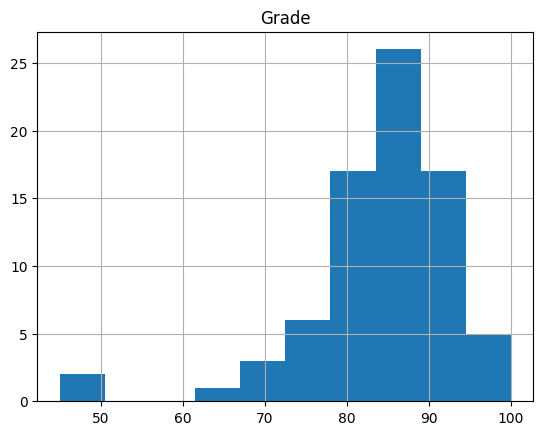

In [ ]:
# basic histogram *the ; removes the text ouput that comes with it
df.hist();

In [ ]:
# range 
df.Grade.max() - df.Grade.min()

np.float64(55.0)

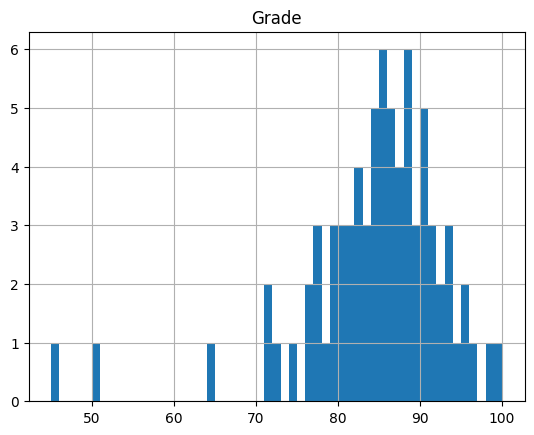

In [ ]:
# histogram with the range 55 
df.hist(bins=55);

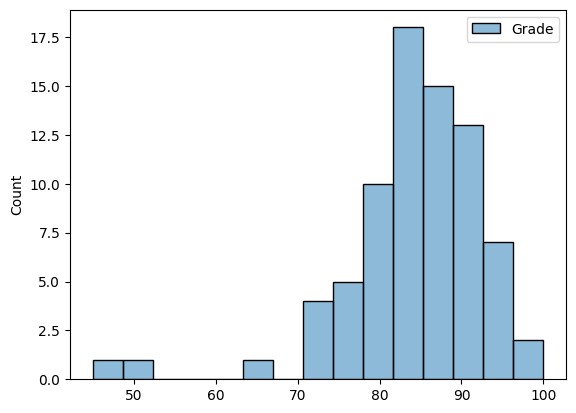

In [ ]:
import seaborn as sns
sns.histplot(df);

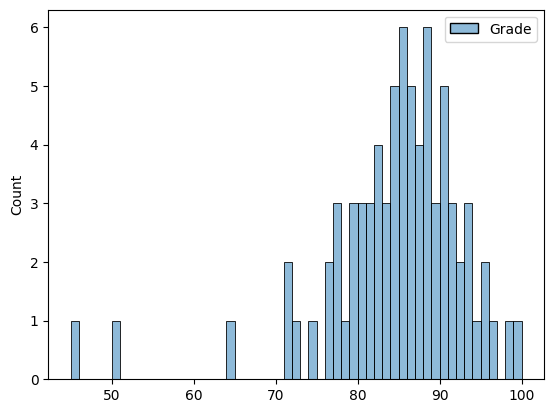

In [ ]:
# updating the bin number: (1 grade within each bar)
sns.histplot(df, binwidth=1);

### 2. Box Plots

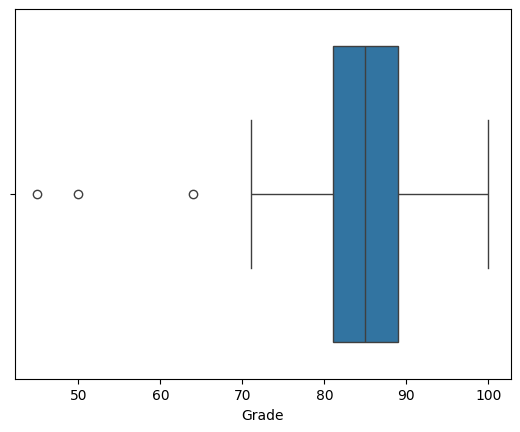

In [ ]:
sns.boxplot(x=df.Grade);
# 3 outliers

In [ ]:
import numpy as np

In [ ]:
q25, q50, q75 = np.percentile(df.Grade, (25, 50,75))
iqr = q75 - q25
min_grade = q25 - 1.5*iqr
max_grade = q75 + 1.5*iqr

min_grade, q25, q50, q75, max_grade

# get output in int instead of floats:
# print(
#     int(min_grade),
#     int(q25),
#     int(q50),
#     int(q75),
#     int(max_grade)
# )

(np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan),
 np.float64(nan))

In [ ]:
# outliers
df[df.Grade < 69]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0
66,Jaxon,Exploratory Data Analysis,Junior,64.0


### 3. Standard Deviation

In [ ]:
mean = np.mean(df.Grade)
sd = np.std(df.Grade)

print('mean:',int(mean))
print('standard deviation:', int(sd))

mean: 84
standard deviation: 8


In [ ]:
[grade for grade in df.Grade if (grade < mean - 3*sd) or (grade > mean + 3*sd)]

[50.0, 45.0]

### 4. Handling Outliers
- Keep outliers
- Remove an entire row or column with outliers
- Impute outliers with NaN or a substitute like the average, mode, max, etc.
- Resolve outliers based on your domain expertise

### Removing entire rows or columns with outliers

In [ ]:
df.shape
# 79 rows and 4 columns

(79, 4)

In [ ]:
# removing outlier grades less than 60
df[df.Grade < 60]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0


In [ ]:
# dropping the rows with the outliers
df.drop([36, 53])

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
74,Aaron,Exploratory Data Analysis,Junior,85.0
75,Charles,Exploratory Data Analysis,Junior,93.0
76,Connor,Exploratory Data Analysis,Junior,91.0
77,Riley,Exploratory Data Analysis,Junior,87.0


In [ ]:
# alternative: if grade is greater or equal to 60 = keep it
df[df.Grade >= 60] 

,Student,Class,Year,Grade
0,Emma,Freshman Seminar,Freshman,86.0
1,Olivia,Freshman Seminar,Freshman,86.0
2,Noah,Freshman Seminar,Freshman,86.0
3,Sophia,Freshman Seminar,Freshman,87.0
4,Liam,Freshman Seminar,Freshman,90.0
...,...,...,...,...
73,Zoey,Exploratory Data Analysis,Junior,91.0
74,Aaron,Exploratory Data Analysis,Junior,85.0
75,Charles,Exploratory Data Analysis,Junior,93.0
76,Connor,Exploratory Data Analysis,Junior,91.0


### Impute outliers with NaN or a substitutes 

In [ ]:
df[df.Grade < 60]

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,50.0
53,Wyatt,Intro to SQL,Sophomore,45.0


In [ ]:
# minimum grade of ppl w grades that are not outliers = 64
min_grade = df[df.Grade >= 60].Grade.min()
min_grade

np.float64(64.0)

In [ ]:
'''if grade is less than 60, then replate it with the min grade, 
keep the original grade'''
df.Grade = np.where(df.Grade < 60, min_grade, df.Grade)
df.Grade

0     86.0
1     86.0
2     86.0
3     87.0
4     90.0
      ... 
74    85.0
75    93.0
76    91.0
77    87.0
78     NaN
Name: Grade, Length: 79, dtype: float64

In [ ]:
df[df.Grade < 60]
# grades below 60 have been replaced

,Student,Class,Year,Grade


In [ ]:
df.loc[[36, 53]]
# now outliers are both 64

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,64.0
53,Wyatt,Intro to SQL,Sophomore,64.0


### Resolving outliers based on domain expertise

In [ ]:
df[df.Student == 'John']

,Student,Class,Year,Grade
36,John,Intro to Python,Freshman,64.0


In [ ]:
# update grade to 74
df.loc[36, 'Grade'] = 74

## 6. Data Issues Review/Check

In [ ]:
# missing values 
df[df.isna().any(axis=1)]   

,Student,Class,Year,Grade
59,Landon,Exploratory Data Analysis,Junior,NaN
78,Gavin,Exploratory Data Analysis,Senior,NaN


In [ ]:
# inconsistent text and typos
df.Class.value_counts()

Class
Intro to Python              25
Exploratory Data Analysis    24
Intro to SQL                 18
Freshman Seminar             12
Name: count, dtype: int64

In [ ]:
# duplicate data
df[df.duplicated()]

,Student,Class,Year,Grade


<Axes: ylabel='Count'>

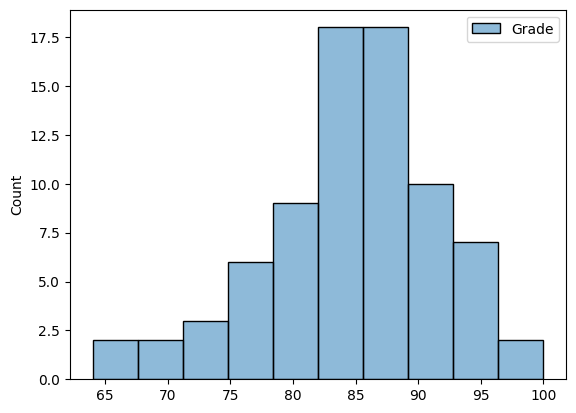

In [ ]:
# outliers 
sns.histplot(df)

## 7. Create Columns From Numeric Data

In [ ]:
run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee
0,Alexis,9.2343,3.5,school,2023-04-15 12:00:00,2023-06-01,False,0.0
1,Alexis,10.3842,3.5,school,2023-04-22 12:30:00,2023-06-01,True,0.0
2,Alexis,8.1209,3.0,gym,2023-05-10 15:00:00,2023-06-01,False,2.5
3,David,7.2123,2.2,school,2023-05-01 15:15:00,2023-06-15,False,0.0
4,David,6.8342,2.0,gym,2023-05-10 16:30:00,2023-06-15,False,2.5


In [ ]:
# update all gym fees to include tax 
#  if location is gym -> increase the fee with Tax, otherwise do nothing
run_times['Fee with Tax'] = np.where(
    run_times.Location == 'gym', run_times.Fee * 1.08, run_times.Fee)

run_times

,Name,Run Time,Warm Up Time,Location,Run Date,Race Date,Rain,Fee,Fee with Tax
0,Alexis,9.2343,3.5,school,2023-04-15 12:00:00,2023-06-01,False,0.0,0.0
1,Alexis,10.3842,3.5,school,2023-04-22 12:30:00,2023-06-01,True,0.0,0.0
2,Alexis,8.1209,3.0,gym,2023-05-10 15:00:00,2023-06-01,False,2.5,2.7
3,David,7.2123,2.2,school,2023-05-01 15:15:00,2023-06-15,False,0.0,0.0
4,David,6.8342,2.0,gym,2023-05-10 16:30:00,2023-06-15,False,2.5,2.7


In [ ]:
groceries = pd.read_excel('Groceries.xlsx')

In [ ]:
groceries[10:21]

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment
10,P100020,Produce: Meat,Beef,8.99,145,2023-06-13 07:00:00,2023-06-17
11,P100021,Produce: Meat,Chicken (Organic),10.49,284,2023-06-13 07:20:00,2023-06-17
12,P100022,Produce: Meat,Turkey,7.99,188,2023-06-13 07:32:00,2023-06-17
13,P100023,Produce: Dairy,Butter,3.50,400,2023-06-13 08:35:00,2023-06-17
14,P100024,Produce: Dairy,Eggs,3.29,234,2023-06-13 08:54:00,2023-06-17
15,P100025,Produce: Dairy,Milk (Soy),4.49,32,2023-06-13 08:37:00,2023-06-17
16,P100026,Produce: Dairy,Yogurt,1.00,432,2023-06-13 08:41:00,2023-06-17
17,P100027,Pantry: Snacks,Apple Sauce - organic,1.50,27,2023-06-10 12:02:00,2023-06-24
18,P100028,Pantry: Snacks,Chips,2.50,365,2023-06-10 12:12:00,2023-06-24
19,P100029,Pantry: Snacks,Cookies (Oatmeal),5.39,340,2023-06-10 12:24:00,2023-06-24


In [ ]:
groceries['New Column'] = round(groceries.Price_Dollars * 1.05, 2)

In [ ]:
groceries.Inventory.sum()

np.int64(4857)

In [ ]:
groceries['Total Inventory'] = groceries.Inventory.sum()

In [ ]:
groceries['Percentage Inventory'] = round(
    groceries['Inventory'] / groceries['Total Inventory'] * 100, 2)

In [ ]:
groceries['Low Inventory'] = np.where(groceries.Inventory < 50, 'Low Inventory', '')

## 8. Create Columns From DateTime Data

In [ ]:
# extract the day from the date in 'run_times' data:
run_times['Run Date'].dt.day

0    15
1    22
2    10
3     1
4    10
Name: Run Date, dtype: int32

In [ ]:
# extract the day of the week
run_times['Run Date'].dt.dayofweek

0    5
1    5
2    2
3    0
4    2
Name: Run Date, dtype: int32

In [ ]:
# extract the time
run_times['Run Date'].dt.time

0    12:00:00
1    12:30:00
2    15:00:00
3    15:15:00
4    16:30:00
Name: Run Date, dtype: object

In [ ]:
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New Column,Total Inventory,Percentage Inventory,Low Inventory
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,


In [ ]:
# extract time 
groceries['Last_Updated_Time'] = groceries.Last_Updated.dt.time

In [ ]:
# extract days of the week for 'scheduled shipment'
groceries['Shipment_Date_DOW'] = groceries.Next_Scheduled_Shipment.dt.dayofweek

In [ ]:
dow_mapping = {
    0: 'Monday',
    1: 'Tuesday',
    2: 'Wednesday',
    3: 'Thursday',
    4: 'Friday',
    5: 'Saturday',
    6: 'Sunday',
}

In [ ]:
groceries['Shipment_Date_DOW'] = groceries['Shipment_Date_DOW'].map(dow_mapping)

In [ ]:
# adding 1 day
groceries ['New_Shipment_Date'] = groceries.Next_Scheduled_Shipment + pd.to_timedelta(1, 'D')

In [ ]:
# if category is fruit -> add 1 day to shipment date, otherwise leave as is 
groceries ['New_Shipment_Date'] = np.where(groceries.Category == 'Produce: Fruit',
         groceries.Next_Scheduled_Shipment + pd.to_timedelta(1, 'D'),
         groceries.Next_Scheduled_Shipment)

In [ ]:
groceries.head(20)

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New Column,Total Inventory,Percentage Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW,New_Shipment_Date
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16
5,P100015,Produce: Fruit,Watermelon,5.99,99,2023-06-12 19:15:00,2023-06-15,6.29,4857,2.04,,19:15:00,Thursday,2023-06-16
6,P100016,Produce: Vegetable,Cabbage,1.78,78,2023-06-12 19:25:00,2023-06-15,1.87,4857,1.61,,19:25:00,Thursday,2023-06-15
7,P100017,Produce: Vegetable,Carrots,2.00,200,2023-06-12 18:05:00,2023-06-15,2.10,4857,4.12,,18:05:00,Thursday,2023-06-15
8,P100018,Produce: Vegetable,Celery,1.99,50,2023-06-12 16:42:00,2023-06-15,2.09,4857,1.03,,16:42:00,Thursday,2023-06-15
9,P100019,Produce: Vegetable,Cucumber,0.99,230,2023-06-12 17:47:00,2023-06-15,1.04,4857,4.74,,17:47:00,Thursday,2023-06-15


## 9. Create Columns From Text Data

In [ ]:
groceries.head()

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New Column,Total Inventory,Percentage Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW,New_Shipment_Date
0,P100010,Produce: Fruit,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16
1,P100011,Produce: Fruit,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16
2,P100012,Produce: Fruit,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16
3,P100013,Produce: Fruit,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16
4,P100014,Produce: Fruit,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16


In [ ]:
# getting rid of 'P' in Product ID to only get numerical data
groceries['Product_ID_Num'] = groceries.Product_ID.str[1:]

In [ ]:
groceries.dtypes

Product_ID                            str
Category                              str
Item                                  str
Price_Dollars                     float64
Inventory                           int64
Last_Updated               datetime64[us]
Next_Scheduled_Shipment    datetime64[us]
New Column                        float64
Total Inventory                     int64
Percentage Inventory              float64
Low Inventory                         str
Last_Updated_Time                  object
Shipment_Date_DOW                     str
New_Shipment_Date          datetime64[us]
Product_ID_Num                        str
dtype: object

In [ ]:
# change 'Product_ID_Num' datatype from object to numeric (int)
groceries['Product_ID_Num'] = groceries['Product_ID_Num'].astype('int')

In [ ]:
groceries.Category.value_counts()

Category
Produce: Fruit           6
Produce: Vegetable       4
Produce: Dairy           4
Pantry: Snacks           4
Produce: Meat            3
Frozen: Frozen Snacks    2
Frozen: Frozen Fruit     2
Name: count, dtype: int64

In [ ]:
# split groceries categories and change to dataFrame
groceries[['Category', 'Subcategory']] = pd.DataFrame(groceries.Category.str.split(':').to_list())

In [ ]:
# if item contains 'Organic', create a new column for it
groceries['Organic'] = groceries.Item.str.contains('Organic|organic', regex=True)

# other method is just using str.lower() to convert to lowercase 
# groceries.Item.str.lower().str.contains('organic')

In [ ]:
groceries.head(10)

,Product_ID,Category,Item,Price_Dollars,Inventory,Last_Updated,Next_Scheduled_Shipment,New Column,Total Inventory,Percentage Inventory,Low Inventory,Last_Updated_Time,Shipment_Date_DOW,New_Shipment_Date,Product_ID_Num,Subcategory,Organic
0,P100010,Produce,Apple,1.50,349,2023-06-12 15:35:00,2023-06-15,1.58,4857,7.19,,15:35:00,Thursday,2023-06-16,100010,Fruit,False
1,P100011,Produce,Banana,0.40,500,2023-06-12 18:30:00,2023-06-15,0.42,4857,10.29,,18:30:00,Thursday,2023-06-16,100011,Fruit,False
2,P100012,Produce,Grapes,4.00,200,2023-06-12 17:22:00,2023-06-15,4.20,4857,4.12,,17:22:00,Thursday,2023-06-16,100012,Fruit,False
3,P100013,Produce,Grapefruit,0.99,50,2023-06-12 16:29:00,2023-06-15,1.04,4857,1.03,,16:29:00,Thursday,2023-06-16,100013,Fruit,False
4,P100014,Produce,Organic Strawberries,3.99,148,2023-06-12 18:10:00,2023-06-15,4.19,4857,3.05,,18:10:00,Thursday,2023-06-16,100014,Fruit,True
5,P100015,Produce,Watermelon,5.99,99,2023-06-12 19:15:00,2023-06-15,6.29,4857,2.04,,19:15:00,Thursday,2023-06-16,100015,Fruit,False
6,P100016,Produce,Cabbage,1.78,78,2023-06-12 19:25:00,2023-06-15,1.87,4857,1.61,,19:25:00,Thursday,2023-06-15,100016,Vegetable,False
7,P100017,Produce,Carrots,2.00,200,2023-06-12 18:05:00,2023-06-15,2.10,4857,4.12,,18:05:00,Thursday,2023-06-15,100017,Vegetable,False
8,P100018,Produce,Celery,1.99,50,2023-06-12 16:42:00,2023-06-15,2.09,4857,1.03,,16:42:00,Thursday,2023-06-15,100018,Vegetable,False
9,P100019,Produce,Cucumber,0.99,230,2023-06-12 17:47:00,2023-06-15,1.04,4857,4.74,,17:47:00,Thursday,2023-06-15,100019,Vegetable,False


In [ ]:
# reorganize categories
groceries[['Product_ID', 'Product_ID_Num', 'Category', 'Subcategory',
           'Item', 'Organic', 'Price_Dollars',
           'Inventory', 'Percentage Inventory', 'Low Inventory',
           'Last_Updated', 'Last_Updated_Time',
           'New_Shipment_Date', 'Shipment_Date_DOW'
           ]].head()

,Product_ID,Product_ID_Num,Category,Subcategory,Item,Organic,Price_Dollars,Inventory,Percentage Inventory,Low Inventory,Last_Updated,Last_Updated_Time,New_Shipment_Date,Shipment_Date_DOW
0,P100010,100010,Produce,Fruit,Apple,False,1.50,349,7.19,,2023-06-12 15:35:00,15:35:00,2023-06-16,Thursday
1,P100011,100011,Produce,Fruit,Banana,False,0.40,500,10.29,,2023-06-12 18:30:00,18:30:00,2023-06-16,Thursday
2,P100012,100012,Produce,Fruit,Grapes,False,4.00,200,4.12,,2023-06-12 17:22:00,17:22:00,2023-06-16,Thursday
3,P100013,100013,Produce,Fruit,Grapefruit,False,0.99,50,1.03,,2023-06-12 16:29:00,16:29:00,2023-06-16,Thursday
4,P100014,100014,Produce,Fruit,Organic Strawberries,True,3.99,148,3.05,,2023-06-12 18:10:00,18:10:00,2023-06-16,Thursday


In [ ]:
groceries_with_new_columns = groceries[['Product_ID', 'Product_ID_Num', 'Category', 'Subcategory',
           'Item', 'Organic', 'Price_Dollars',
           'Inventory', 'Percentage Inventory', 'Low Inventory',
           'Last_Updated', 'Last_Updated_Time',
           'New_Shipment_Date', 'Shipment_Date_DOW'
           ]]

In [ ]:
# save to_pickle
groceries_with_new_columns.to_pickle('groceries_with_new_columns.pkl')